In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from itertools import combinations
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
for i in range(10):
    file_path = f"./Syn93_mrt_{i+1}.pickle"
    if os.path.exists(file_path):
        print(f"{file_path} - Size: {os.path.getsize(file_path)} bytes")
    else:
        print(f"{file_path} - File does not exist!")

./Syn93_mrt_1.pickle - Size: 15592362 bytes
./Syn93_mrt_2.pickle - Size: 15592362 bytes
./Syn93_mrt_3.pickle - Size: 15592362 bytes
./Syn93_mrt_4.pickle - Size: 15592362 bytes
./Syn93_mrt_5.pickle - Size: 15592362 bytes
./Syn93_mrt_6.pickle - Size: 15592362 bytes
./Syn93_mrt_7.pickle - Size: 15592362 bytes
./Syn93_mrt_8.pickle - Size: 15592362 bytes
./Syn93_mrt_9.pickle - Size: 15592362 bytes
./Syn93_mrt_10.pickle - Size: 15592362 bytes


In [ ]:
data_frames = []
for i in range(10):
    loaded_data = pd.read_pickle(f"./Syn93_mrt_{i+1}.pickle")
    if isinstance(loaded_data, list):
        loaded_data = pd.DataFrame(loaded_data)
    data_frames.append(loaded_data)

df = pd.concat(data_frames, ignore_index=True)

In [6]:
df.describe()

,pl_orbper,pl_orbsmax,pl_radj,pl_massj,pl_eqt,Coeff,b1,st_teff,st_rad,st_mass,...,i_bw,i,i_bw_err_low,i_bw_err_up,i_err,z_bw,z,z_bw_err_low,z_bw_err_up,z_err
count,100000.0,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.0,100000.0,...,1.000000e+05,100000.000000,1.000000e+05,1.000000e+05,100000.000000,1.000000e+05,100000.000000,1.000000e+05,1.000000e+05,100000.000000
mean,1.0,1.957212e-02,0.912940,15.910660,924.945236,1.032230,0.341604,5500.0,1.0,1.0,...,7.486023e+03,0.008892,5.837262e+02,6.854328e+02,0.000081,8.955061e+03,0.008888,6.841727e+02,4.942682e+02,0.000074
std,0.0,3.591936e-14,0.055915,8.997075,463.359762,0.127169,0.017531,0.0,0.0,0.0,...,1.229916e-08,0.001094,4.426988e-10,6.607512e-10,0.000010,1.858471e-08,0.001092,9.716863e-10,7.597729e-10,0.000009
min,1.0,1.957212e-02,0.800007,0.362356,500.003007,0.515191,0.263560,5500.0,1.0,1.0,...,7.486023e+03,0.006763,5.837262e+02,6.854328e+02,0.000061,8.955061e+03,0.006762,6.841727e+02,4.942682e+02,0.000056
25%,1.0,1.957212e-02,0.867890,8.073582,616.708161,0.947433,0.329904,5500.0,1.0,1.0,...,7.486023e+03,0.007996,5.837262e+02,6.854328e+02,0.000073,8.955061e+03,0.007992,6.841727e+02,4.942682e+02,0.000066
50%,1.0,1.957212e-02,0.918789,15.907171,776.529329,1.033714,0.341725,5500.0,1.0,1.0,...,7.486023e+03,0.008969,5.837262e+02,6.854328e+02,0.000081,8.955061e+03,0.008965,6.841727e+02,4.942682e+02,0.000074
75%,1.0,1.957212e-02,0.961298,23.690360,1061.661980,1.118601,0.353494,5500.0,1.0,1.0,...,7.486023e+03,0.009823,5.837262e+02,6.854328e+02,0.000089,8.955061e+03,0.009818,6.841727e+02,4.942682e+02,0.000081
max,1.0,1.957212e-02,0.999999,31.466073,3997.554158,1.664071,0.419057,5500.0,1.0,1.0,...,7.486023e+03,0.016958,5.837262e+02,6.854328e+02,0.000153,8.955061e+03,0.016444,6.841727e+02,4.942682e+02,0.000142


In [7]:
df

,pl_orbper,pl_orbsmax,pl_radj,pl_massj,pl_eqt,Coeff,b1,st_teff,st_rad,st_mass,...,i_bw,i,i_bw_err_low,i_bw_err_up,i_err,z_bw,z,z_bw_err_low,z_bw_err_up,z_err
0,1,0.019572,0.982913,9.028319,1333.208737,1.100311,0.320080,5500,1,1,...,7486.022892,0.010276,583.726235,685.432784,0.000093,8955.060521,0.010273,684.172662,494.268237,0.000085
1,1,0.019572,0.906402,1.961081,629.110864,1.241706,0.326048,5500,1,1,...,7486.022892,0.008803,583.726235,685.432784,0.000080,8955.060521,0.008788,684.172662,494.268237,0.000073
2,1,0.019572,0.916328,27.009671,608.376919,1.066579,0.353166,5500,1,1,...,7486.022892,0.008873,583.726235,685.432784,0.000080,8955.060521,0.008872,684.172662,494.268237,0.000074
3,1,0.019572,0.943680,9.227830,560.106668,1.183514,0.345988,5500,1,1,...,7486.022892,0.009420,583.726235,685.432784,0.000085,8955.060521,0.009419,684.172662,494.268237,0.000078
4,1,0.019572,0.885380,13.788546,928.160370,0.973283,0.339702,5500,1,1,...,7486.022892,0.008289,583.726235,685.432784,0.000075,8955.060521,0.008288,684.172662,494.268237,0.000069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,0.019572,0.971792,31.233374,868.007501,1.071154,0.342669,5500,1,1,...,7486.022892,0.009990,583.726235,685.432784,0.000091,8955.060521,0.009988,684.172662,494.268237,0.000083
99996,1,0.019572,0.862298,17.156403,683.355272,1.116959,0.330496,5500,1,1,...,7486.022892,0.007861,583.726235,685.432784,0.000071,8955.060521,0.007860,684.172662,494.268237,0.000065
99997,1,0.019572,0.988605,3.616451,619.230955,1.003496,0.373489,5500,1,1,...,7486.022892,0.010433,583.726235,685.432784,0.000095,8955.060521,0.010420,684.172662,494.268237,0.000087
99998,1,0.019572,0.921262,17.485540,750.140583,1.133354,0.333631,5500,1,1,...,7486.022892,0.008973,583.726235,685.432784,0.000081,8955.060521,0.008972,684.172662,494.268237,0.000074


In [8]:
df.columns

Index(['pl_orbper', 'pl_orbsmax', 'pl_radj', 'pl_massj', 'pl_eqt', 'Coeff',
       'b1', 'st_teff', 'st_rad', 'st_mass', 'MR_TiO', 'MR_VO', 'U_bw', 'U',
       'U_bw_err_low', 'U_bw_err_up', 'U_err', 'B_bw', 'B', 'B_bw_err_low',
       'B_bw_err_up', 'B_err', 'V_bw', 'V', 'V_bw_err_low', 'V_bw_err_up',
       'V_err', 'R_bw', 'R', 'R_bw_err_low', 'R_bw_err_up', 'R_err', 'I_bw',
       'I', 'I_bw_err_low', 'I_bw_err_up', 'I_err', 'u_bw', 'u',
       'u_bw_err_low', 'u_bw_err_up', 'u_err', 'g_bw', 'g', 'g_bw_err_low',
       'g_bw_err_up', 'g_err', 'r_bw', 'r', 'r_bw_err_low', 'r_bw_err_up',
       'r_err', 'i_bw', 'i', 'i_bw_err_low', 'i_bw_err_up', 'i_err', 'z_bw',
       'z', 'z_bw_err_low', 'z_bw_err_up', 'z_err'],
      dtype='object')

### Preprocessing

In [ ]:
target_data = np.log10(df[['pl_eqt', 'MR_TiO', 'MR_VO']])

bands = ['U', 'B', 'V', 'R', 'I', 'u', 'g', 'r', 'i', 'z']

error_cols = [col for col in df.columns if col.endswith('_err') and col[:-4] in bands]

norm_depth = df[bands + error_cols].div(df['pl_radj']**2, axis=0)

In [ ]:
scaler = StandardScaler()
norm_depth_scaled = scaler.fit_transform(norm_depth)
norm_depth_scaled_df = pd.DataFrame(norm_depth_scaled, columns=norm_depth.columns)

In [ ]:
train = norm_depth_scaled_df.values
target = target_data.values
X_train, X_test, y_train, y_test = train_test_split(
    train, target, test_size=0.20, random_state=101, shuffle=False
)

### Splitting data

In [ ]:
train_ratio = 0.70
validation_ratio = 0.20
test_ratio = 0.10

x_train, x_temp, y_train, y_temp = train_test_split(
    X_train, y_train, test_size=1 - train_ratio, random_state=101, shuffle=False
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=test_ratio / (test_ratio + validation_ratio), random_state=101, shuffle=False
)

In [15]:
print(f"x_train shape: {x_train.shape}")
print(f"x_val shape: {x_val.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (55999, 20)
x_val shape: (16000, 20)
x_test shape: (8001, 20)


### Tuning hyperparameters, Trainning & Prediction

In [ ]:
param_grid = {
    'n_estimators': np.logspace(1, 3, num=10, dtype=int),
    'max_depth': np.logspace(1, 2, num=10, dtype=int)
}
run_num = 93

grid_result = GridSearchCV(
    estimator=RandomForestRegressor(random_state=101),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=10,
    verbose=1,
    return_train_score=True
)

start_time = time.time()

grid_result.fit(x_train, y_train)
joblib.dump(grid_result, 'grid_checkpoint.pkl')

df1 = pd.DataFrame(grid_result.cv_results_)
df1.to_csv(f'GridCV_res_{run_num}.csv', index=False)
joblib.dump(grid_result.best_estimator_, f"GridCV_best_model_{run_num}.pkl", compress=1)

end_time = time.time()
print(f"Grid Search completed in {(end_time - start_time) / 60:.2f} minutes.")

print("Predicting...")
best_model = grid_result.best_estimator_
train_pred = best_model.predict(x_train)
val_pred = best_model.predict(x_val)
test_pred = best_model.predict(x_test)

dict_train = {
    'pl_eqt_train': y_train[:, 0], 'pl_eqt_train_pred': train_pred[:, 0],
    'mr_TiO_train': y_train[:, 1], 'mr_TiO_train_pred': train_pred[:, 1],
    'mr_VO_train': y_train[:, 2],  'mr_VO_train_pred': train_pred[:, 2]
}

dict_test = {
    'pl_eqt_test': y_test[:, 0], 'pl_eqt_test_pred': test_pred[:, 0],
    'mr_TiO_test': y_test[:, 1], 'mr_TiO_test_pred': test_pred[:, 1],
    'mr_VO_test': y_test[:, 2],  'mr_VO_test_pred': test_pred[:, 2]
}
dict_val = {
    'pl_eqt_val': y_val[:, 0], 'pl_eqt_val_pred': val_pred[:, 0],
    'mr_TiO_val': y_val[:, 1], 'mr_TiO_val_pred': val_pred[:, 1],
    'mr_VO_val': y_val[:, 2],  'mr_VO_val_pred': val_pred[:, 2]
}

pd.DataFrame(dict_train).to_csv(f'pred_res_train_{run_num}.csv', index=False)
pd.DataFrame(dict_test).to_csv(f'pred_res_test_{run_num}.csv', index=False)
pd.DataFrame(dict_val).to_csv(f'pred_res_val_{run_num}.csv', index=False)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


In [ ]:
print("Best Score: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best Score: 0.825512 using {'max_depth': 46, 'n_estimators': 1000}
0.439675 (0.007042) with: {'max_depth': 10, 'n_estimators': 10}
0.443767 (0.006073) with: {'max_depth': 10, 'n_estimators': 16}
0.446545 (0.006645) with: {'max_depth': 10, 'n_estimators': 27}
0.450148 (0.004783) with: {'max_depth': 10, 'n_estimators': 46}
0.451878 (0.004385) with: {'max_depth': 10, 'n_estimators': 77}
0.453342 (0.004898) with: {'max_depth': 10, 'n_estimators': 129}
0.454261 (0.005238) with: {'max_depth': 10, 'n_estimators': 215}
0.455007 (0.004716) with: {'max_depth': 10, 'n_estimators': 359}
0.454758 (0.004725) with: {'max_depth': 10, 'n_estimators': 599}
0.454985 (0.004574) with: {'max_depth': 10, 'n_estimators': 1000}
0.508435 (0.007732) with: {'max_depth': 12, 'n_estimators': 10}
0.513039 (0.006584) with: {'max_depth': 12, 'n_estimators': 16}
0.516239 (0.007565) with: {'max_depth': 12, 'n_estimators': 27}
0.519479 (0.004558) with: {'max_depth': 12, 'n_estimators': 46}
0.521114 (0.003731) with: {'max

In [ ]:
run_num = 93
train_results = pd.read_csv(f'pred_res_train_{run_num}.csv')
val_results = pd.read_csv(f'pred_res_val_{run_num}.csv')
test_results = pd.read_csv(f'pred_res_test_{run_num}.csv')

In [14]:
val_results.describe()

,pl_eqt_val,pl_eqt_val_pred,mr_TiO_val,mr_TiO_val_pred,mr_VO_val,mr_VO_val_pred
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,2.925777,2.923925,-2.518569,-2.509830,-2.490648,-2.479335
std,0.171590,0.144115,0.871897,0.698656,0.869290,0.739227
min,2.698993,2.711308,-3.999964,-3.791170,-4.000000,-3.910282
25%,2.790775,2.812030,-3.284138,-3.127876,-3.242972,-3.101378
50%,2.889445,2.885886,-2.535235,-2.554201,-2.478166,-2.514946
75%,3.024443,3.009193,-1.765674,-1.925460,-1.738806,-1.856927
max,3.599900,3.496427,-1.000003,-1.030409,-1.000027,-1.036508


In [15]:
test_results.describe()

,pl_eqt_test,pl_eqt_test_pred,mr_TiO_test,mr_TiO_test_pred,mr_VO_test,mr_VO_test_pred
count,8001.000000,8001.000000,8001.000000,8001.000000,8001.000000,8001.000000
mean,2.927769,2.925889,-2.500826,-2.496153,-2.508340,-2.498285
std,0.171914,0.145059,0.868452,0.691212,0.872407,0.740943
min,2.699001,2.703880,-3.999935,-3.806878,-3.999804,-3.891736
25%,2.789198,2.811524,-3.263322,-3.108273,-3.275750,-3.127775
50%,2.892518,2.888534,-2.502308,-2.530511,-2.521619,-2.541628
75%,3.030872,3.014616,-1.746223,-1.918214,-1.750991,-1.890747
max,3.599614,3.455345,-1.001179,-1.045825,-1.000364,-1.038813


### Visualisation

In [ ]:
mpl.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman'],
    'text.usetex'      : True,
    'font.size'        : 24,
    'font.weight'      : 'bold', 
    'axes.labelweight' : 'bold',
})

def plot_results_with_r2_heatmap(train_df, val_df, test_df, target_vars, ranges, fz_axis=18, fz_labels=16, fz_legend=20, grid_w=0.5, dash_w=3, save_path='train_val_test_results_with_r2_heatmap.jpeg'):
    """
    Plots separate hexbin subplots for training, validation, and test results with R^2 labels.

    Parameters:
    - train_df, val_df, test_df: DataFrames with columns for actual and predicted values for each variable
    - target_vars: List of column name suffixes (e.g., ['pl_eqt', 'mr_TiO', 'mr_VO'])
    - ranges: list of tuples, ranges for x and y axes for each variable
    - fz_axis, fz_labels, fz_legend: font sizes for labels and legend
    - grid_w, dash_w: line widths for grid and dashed line
    - save_path: path to save the plot image
    """
    nrows, ncols = len(target_vars), 3
    fig, ax = plt.subplots(nrows, ncols, figsize=(7 * ncols, 7 * nrows), squeeze=False)

    for i, (target, range_) in enumerate(zip(target_vars, ranges)):
        if target in ['mr_TiO', 'mr_VO']:
            real_train = train_df[f"{target}_train"]
            pred_train = train_df[f"{target}_train_pred"]
            real_val = val_df[f"{target}_val"]
            pred_val = val_df[f"{target}_val_pred"]
            real_test = test_df[f"{target}_test"]
            pred_test = test_df[f"{target}_test_pred"]
        else:
            real_train = train_df[f"{target}_train"]
            pred_train = train_df[f"{target}_train_pred"]
            real_val = val_df[f"{target}_val"]
            pred_val = val_df[f"{target}_val_pred"]
            real_test = test_df[f"{target}_test"]
            pred_test = test_df[f"{target}_test_pred"]

        r2_train = r2_score(real_train, pred_train)
        r2_val = r2_score(real_val, pred_val)
        r2_test = r2_score(real_test, pred_test)
        cmap = 'Blues'
        b='black'
        label_map = {"pl_eqt": r"log($T_p$)",
                     "mr_TiO": r"log($X_{\rm{TiO}}$)",
                     "mr_VO": r"log($X_{\rm{VO}}$)"}

        if i == 0:
            ax[i, 0].set_title("Train", fontsize=fz_axis)
            ax[i, 1].set_title("Validation", fontsize=fz_axis)
            ax[i, 2].set_title("Test", fontsize=fz_axis)
        
        x_label = f"Real {label_map.get(target, target)}"
        y_label = f"Predicted {label_map.get(target, target)}"
        xy_range = range_[0]
        
        tick_step = round((xy_range[1] - xy_range[0]) / 5, 2)
        ticks = np.arange(xy_range[0], xy_range[1] + tick_step, tick_step)

        for col in range(3):
            a = ax[i, col]
            a.set_xlim(xy_range)
            a.set_ylim(xy_range)
            a.set_aspect('equal')

            a.set_xticks(ticks)
            a.set_yticks(ticks)
            
            a.yaxis.set_tick_params(labelleft=True)
            a.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}"))
            a.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}"))
            
        hb_train = ax[i, 0].hexbin(real_train, pred_train, gridsize=50, cmap=cmap)
        ax[i, 0].plot([range_[0][0], range_[0][1]], [range_[1][0], range_[1][1]], '--', color='black', linewidth=dash_w)
        ax[i, 0].set_xlabel(x_label, fontsize=fz_labels)
        ax[i, 0].set_ylabel(y_label, fontsize=fz_labels)
        ax[i, 0].grid(True, which='major', linewidth=grid_w)
        ax[i, 0].set_aspect('equal')
        ax[i, 0].tick_params(labelsize=fz_labels)
        ax[i, 0].text(0.05, 0.95, f'$R^2$ = {r2_train:.3f}', transform=ax[i, 0].transAxes, fontsize=fz_legend, verticalalignment='top', color=b)

        hb_val = ax[i, 1].hexbin(real_val, pred_val, gridsize=50, cmap=cmap)
        ax[i, 1].plot([range_[0][0], range_[0][1]], [range_[1][0], range_[1][1]], '--', color='black', linewidth=dash_w)
        ax[i, 1].set_xlabel(x_label, fontsize=fz_labels)
        ax[i, 1].set_ylabel(y_label, fontsize=fz_labels)
        ax[i, 1].grid(True, which='major', linewidth=grid_w)
        ax[i, 1].set_aspect('equal')
        ax[i, 1].tick_params(labelsize=fz_labels)
        ax[i, 1].text(0.05, 0.95, f'$R^2$ = {r2_val:.3f}', transform=ax[i, 1].transAxes, fontsize=fz_legend, verticalalignment='top', color=b)

        hb_test = ax[i, 2].hexbin(real_test, pred_test, gridsize=50, cmap=cmap)
        ax[i, 2].plot([range_[0][0], range_[0][1]], [range_[1][0], range_[1][1]], '--', color='black', linewidth=dash_w)
        ax[i, 2].set_xlabel(x_label, fontsize=fz_labels)
        ax[i, 2].set_ylabel(y_label, fontsize=fz_labels)
        ax[i, 2].grid(True, which='major', linewidth=grid_w)
        ax[i, 2].set_aspect('equal')
        ax[i, 2].tick_params(labelsize=fz_labels)
        ax[i, 2].text(0.05, 0.95, f'$R^2$ = {r2_test:.3f}', transform=ax[i, 2].transAxes, fontsize=fz_legend, verticalalignment='top', color=b)

    plt.tight_layout(pad=0, w_pad=0.05, h_pad=0.05)
    fig.savefig(save_path, dpi=500, transparent=True)
    print(f"Plot saved as {save_path}")
    plt.show()

Plot saved as train_val_test_results_with_r2_heatmap_93-log.pdf


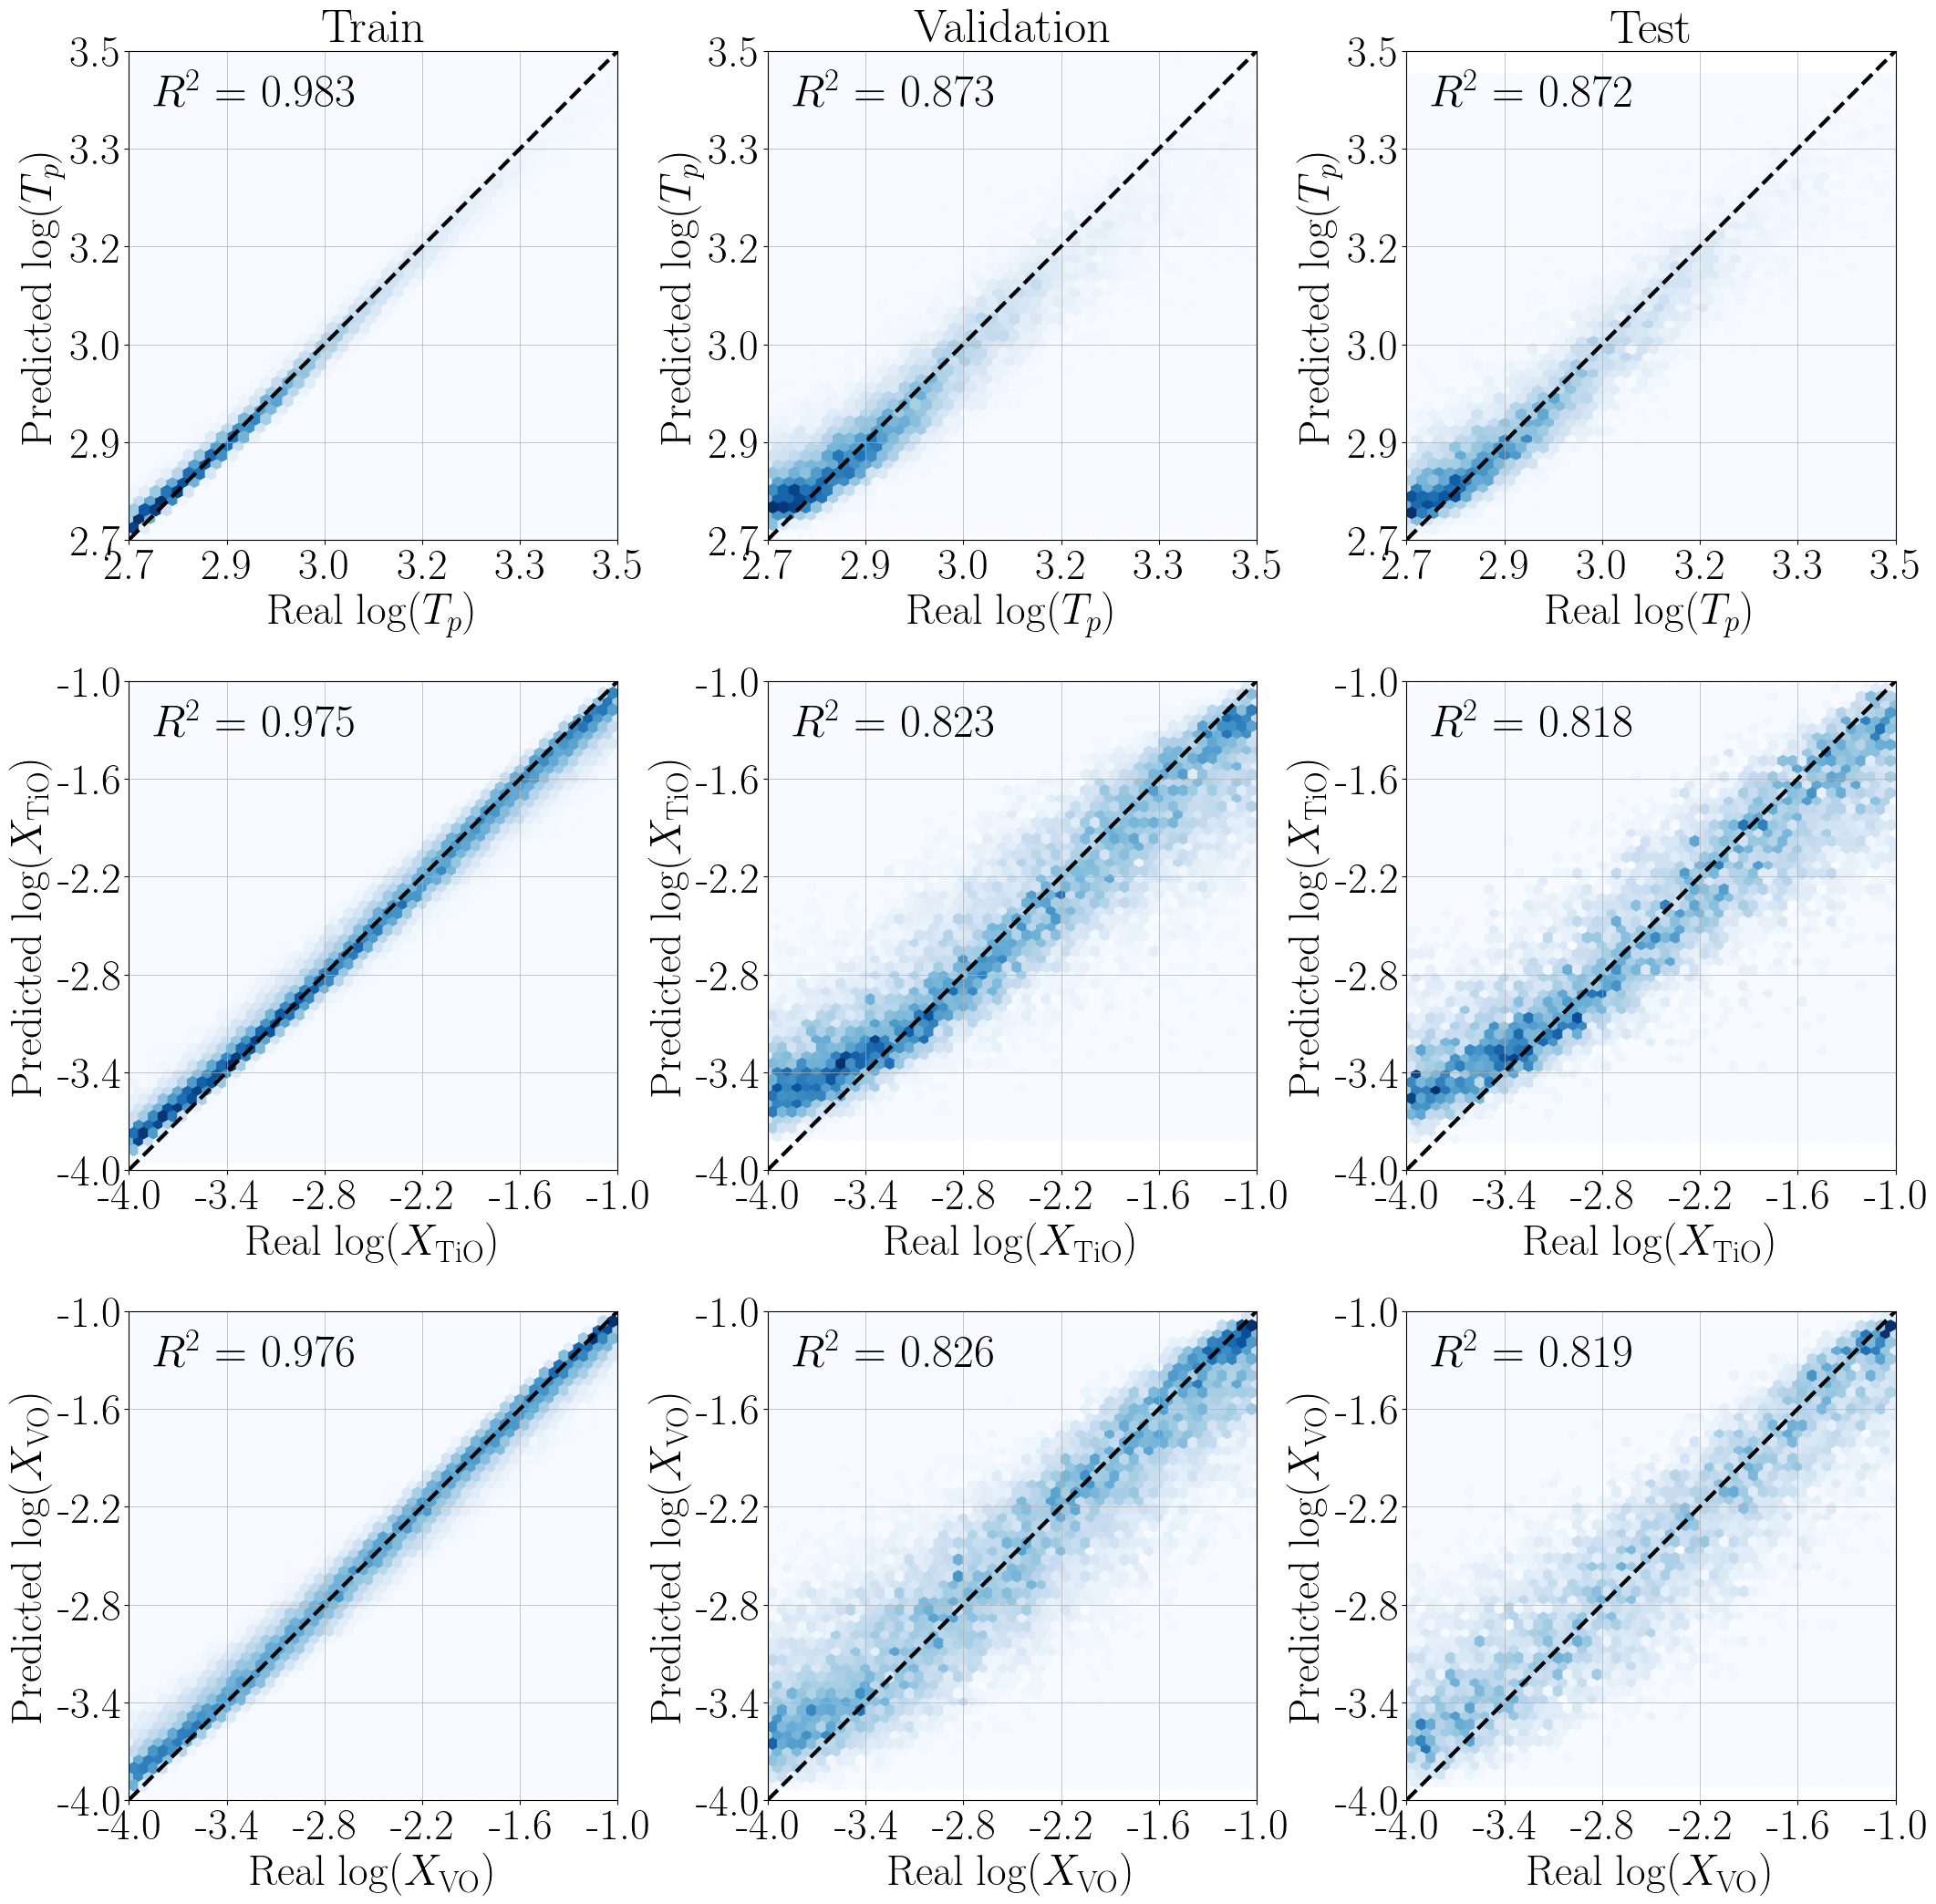

In [ ]:
target_vars = ['pl_eqt', 'mr_TiO', 'mr_VO']
ranges = [
    ((2.7, 3.5), (2.7, 3.5)),      # Range for pl_eqt
    ((-4, -1), (-4, -1)),          # Range for mr_TiO
    ((-4, -1), (-4, -1))           # Range for mr_VO
]

plot_results_with_r2_heatmap(
    train_df=train_results,
    val_df=val_results,
    test_df=test_results,
    target_vars=target_vars,
    ranges=ranges,
    save_path=f'train_val_test_results_with_r2_heatmap_{run_num}-log.pdf',
    fz_axis=38, fz_labels=34, fz_legend=36
)

### Measure prediction time

In [ ]:
run_num = 93
filename = f"GridCV_best_model_{run_num}.pkl"

best_model = joblib.load(filename)

In [17]:
best_model

RandomForestRegressor(max_depth=46, n_estimators=1000, random_state=101)

In [ ]:
start_time = time.time()
y_pred = best_model.predict(x_test[:100])
end_time = time.time()

elapsed_time = end_time - start_time
print(f"Prediction Time: {elapsed_time:.6f} seconds")
print(f"Number of Predictions: {len(y_pred)}")
print(f"Sample Predictions: {y_pred[:10]}")

Prediction Time: 0.099903 seconds
Number of Predictions: 100
Sample Predictions: [[ 2.72251928 -3.1038348  -2.62784774]
 [ 3.28701387 -1.95006872 -2.49394733]
 [ 3.16767369 -3.61923315 -1.39016265]
 [ 3.16628897 -1.88492998 -2.71497929]
 [ 2.88609202 -1.84170831 -2.93976409]
 [ 2.92517454 -2.24874251 -2.56820396]
 [ 2.97552334 -3.2358194  -1.98003152]
 [ 2.86891908 -2.97195108 -1.91403175]
 [ 2.80411393 -2.16834756 -3.34857581]
 [ 2.83468612 -2.31136825 -3.39555718]]


In [ ]:
_ = best_model.predict(x_test[:100])

num_runs = 10
times = []

for _ in range(num_runs):
    start_time = time.time()
    _ = best_model.predict(x_test[:100])
    end_time = time.time()
    times.append(end_time - start_time)

avg_time = np.mean(times)
std_time = np.std(times)
print(f"Average Prediction Time over {num_runs} runs: {avg_time:.6f} seconds (std: {std_time:.6f} seconds)")

Average Prediction Time over 10 runs: 0.092031 seconds (std: 0.000545 seconds)
